<img align="center" style="max-width: 900px; height: auto" src="assets/banner.png">

<img align="right" style="max-width: 200px; height: auto" src="assets/hsg_logo.png">

## Lab 06 - "End-to-End Learning & Neural Networks"

Artificial Intelligence (Spring 2026), University of St. Gallen

In this lab we will explore the building blocks of **(deep) neural networks** from the bottom up.

Objectives:

* Understand the shift from **traditional ML with handcrafted features** to **end-to-end learning**.
* Implement the simplest artificial neurons from scratch: the **McCulloch-Pitts neuron** and the **Rosenblatt perceptron**.
* See why a single neuron cannot solve the **XOR problem**, and how a **Multi-Layer Perceptron (MLP)** can.
* Get familiar with the common **activation functions** and their properties.
* Write a **vectorized forward pass** for an MLP in NumPy and view a neural network as a **nested function**.
* Get a first introduction to **PyTorch** and re-implement our MLP with `torch.nn`.

> Note: training the network (backpropagation, gradient descent) is covered in the next lecture. In this lab we only look at **forward passes** with either hand-set or random weights.

### Part 0: Setup

We will use three libraries:

* [NumPy](https://numpy.org/) for vector/matrix math.
* [Matplotlib](https://matplotlib.org/) for plotting.
* [PyTorch](https://pytorch.org/) for the neural-network part at the end.

In [90]:
!pip3 install numpy matplotlib torch -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [91]:
import numpy as np          # NumPy: numerical computing (arrays, linear algebra)
import matplotlib.pyplot as plt  # Matplotlib: plotting library

np.random.seed(0)  # Fix the random seed for reproducibility

### Part 1: Traditional ML vs. End-to-End Learning

In traditional machine learning, a human expert designs **handcrafted features** (edges, histograms of gradients, SIFT, color histograms, ...) and a separate classifier is trained on top of them:

```
raw input  →  [handcrafted feature extractor]  →  features  →  [classifier]  →  y
```

The feature extractor is **fixed**; only the classifier is learned.

In **end-to-end learning**, features *and* classifier are learned jointly as one cascade of non-linear transformations:

```
raw input  →  [ layer 1 → layer 2 → ... → layer L ]  →  y
                           (all learned together)
```

This means the model learns its **own internal representation** of the input, adapted to the task.

Let's illustrate this with a tiny toy example. We generate two classes of 2D points that are **not linearly separable** in the raw input space, and build a small "handcrafted feature" by hand.

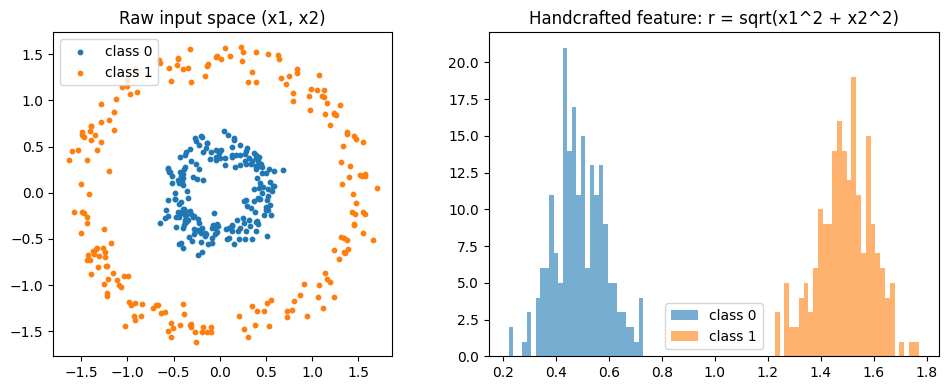

In [92]:
# --- Generate a toy dataset of two concentric rings ---
n = 200  # Number of points per ring
theta = np.random.rand(n) * 2 * np.pi  # Random angles uniformly in [0, 2π)
r_inner = 0.5 + 0.1 * np.random.randn(n)  # Inner ring radii: mean 0.5, std 0.1
r_outer = 1.5 + 0.1 * np.random.randn(n)  # Outer ring radii: mean 1.5, std 0.1

# Convert polar coordinates (r, θ) to Cartesian (x, y) for the inner ring
X_inner = np.stack([r_inner * np.cos(theta), r_inner * np.sin(theta)], axis=1)
# Convert polar coordinates (r, θ) to Cartesian (x, y) for the outer ring
X_outer = np.stack([r_outer * np.cos(theta), r_outer * np.sin(theta)], axis=1)
# Stack both rings into a single (400, 2) array
X = np.vstack([X_inner, X_outer])
# Labels: 0 for inner ring, 1 for outer ring
y = np.array([0] * n + [1] * n)

# --- Plot the raw input space and the handcrafted feature ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))  # Create 1×2 subplot grid

# Left plot: scatter the raw 2D points, colored by class
ax[0].scatter(X[y == 0, 0], X[y == 0, 1], label='class 0', s=10)  # Inner ring
ax[0].scatter(X[y == 1, 0], X[y == 1, 1], label='class 1', s=10)  # Outer ring
ax[0].set_title("Raw input space (x1, x2)")  # Title for the left plot
ax[0].legend(); ax[0].set_aspect('equal')  # Add legend and make axes equal scale

# Handcrafted feature: compute the radius r = sqrt(x1^2 + x2^2) for each point
r = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
# Right plot: histogram of radii, separated by class
ax[1].hist(r[y == 0], bins=30, alpha=0.6, label='class 0')  # Inner ring radii
ax[1].hist(r[y == 1], bins=30, alpha=0.6, label='class 1')  # Outer ring radii
ax[1].set_title("Handcrafted feature: r = sqrt(x1^2 + x2^2)")  # Title
ax[1].legend()  # Add legend
plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Display the figure

Observation: in the raw `(x1, x2)` space the two classes are **interleaved**, so a straight line cannot separate them. But once we apply the handcrafted feature `r = sqrt(x1^2 + x2^2)`, a simple threshold on `r` works perfectly.

The whole idea of end-to-end learning is: **we don't want to design `r` by hand** — we want the network to discover such a useful representation on its own.

### Part 2: The McCulloch-Pitts Neuron (1943)

The very first mathematical model of a neuron. It is extremely simple:

* inputs $x_i \in \{0, 1\}$ (binary)
* no weights — all inputs count equally
* an aggregation function (sum) and a **threshold** $\theta$
* output $y \in \{0, 1\}$:

$$ y = \begin{cases} 1 & \text{if } \sum_i x_i \geq \theta \\ 0 & \text{otherwise} \end{cases} $$

We can implement basic Boolean gates by picking the right threshold.

In [93]:
def mp_neuron(inputs, theta):
    """McCulloch-Pitts neuron: fires if sum of binary inputs >= theta."""
    return int(sum(inputs) >= theta)  # Sum all inputs; return 1 if >= threshold, else 0

# AND: fires only if BOTH inputs are 1  ->  theta = 2
# OR : fires if AT LEAST ONE input is 1 ->  theta = 1
inputs_2 = [(0, 0), (0, 1), (1, 0), (1, 1)]  # All possible 2-bit binary inputs

# Print the truth table header
print(f"{'x1':>3} {'x2':>3} | {'AND':>3} {'OR':>3}")
print("-" * 20)
# Evaluate both AND (theta=2) and OR (theta=1) for each input pair
for x1, x2 in inputs_2:
    print(f"{x1:>3} {x2:>3} | {mp_neuron([x1, x2], 2):>3} {mp_neuron([x1, x2], 1):>3}")

 x1  x2 | AND  OR
--------------------
  0   0 |   0   0
  0   1 |   0   1
  1   0 |   0   1
  1   1 |   1   1


#### Limitation: the XOR problem

XOR fires when **exactly one** input is 1. With a single McCulloch-Pitts neuron (just sum + threshold, equal weights) there is no threshold $\theta$ that reproduces the XOR truth table:

| x1 | x2 | XOR |
|----|----|-----|
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Let's confirm that no single threshold works.

In [94]:
# Try every possible threshold to show that no single one produces XOR.
# With 2 binary inputs the sum is in {0, 1, 2}, so we only need to check
# theta in {0, 1, 2, 3}: any theta > 3 always outputs 0 (same as theta=3),
# and any theta <= 0 always outputs 1 (same as theta=0) — nothing new to learn.
for theta in [0, 1, 2, 3]:
    # Compute the MP neuron output for all 4 input pairs with this threshold
    out = [mp_neuron([x1, x2], theta) for x1, x2 in inputs_2]
    print(f"theta={theta}: outputs={out}")
# The desired XOR output — no single threshold can match it
print("target XOR     : [0, 1, 1, 0]  <-- no single theta reproduces this")

theta=0: outputs=[1, 1, 1, 1]
theta=1: outputs=[0, 1, 1, 1]
theta=2: outputs=[0, 0, 0, 1]
theta=3: outputs=[0, 0, 0, 0]
target XOR     : [0, 1, 1, 0]  <-- no single theta reproduces this


This is the famous **XOR problem** (Minsky, 1969). Other limitations of the McCulloch-Pitts neuron:

* only Boolean inputs/outputs,
* all inputs are treated equally (no weights),
* the threshold $\theta$ has to be **hand-coded** — there is no learning algorithm.

### Part 3: The Rosenblatt Perceptron (1958)

Frank Rosenblatt extended the McCulloch-Pitts neuron with two crucial ideas:

1. **weights** $w_i \in \mathbb{R}$ for every input (not just equal votes),
2. **real-valued inputs** $x_i \in \mathbb{R}$.

The neuron computes

$$ z = \sum_{i=1}^{d} w_i x_i + b = \mathbf{w}^\top \mathbf{x} + b $$

and applies a **step activation**:

$$ y = \varphi(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases} $$

The bias $b$ plays the role of the (negative) threshold. Rosenblatt also proposed a **learning algorithm** for finding the weights from labeled data — we will cover that in the next lecture.

For now we just implement the **forward pass** with hand-set weights.

In [95]:
def step(z):
    """Step activation function: returns 1 where z >= 0, else 0."""
    return (z >= 0).astype(int)  # Element-wise comparison, cast booleans to 0/1

def perceptron_forward(X, w, b):
    """Forward pass of a Rosenblatt perceptron. X: (N, d), w: (d,), b: scalar."""
    z = X @ w + b    # Compute the weighted sum z = Xw + b for all N samples at once
    return step(z)   # Apply the step activation to get binary outputs

# --- Hand-crafted weights for an AND gate ---
X_bool = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # All 2-bit binary inputs as a (4,2) array
w_and = np.array([1.0, 1.0])  # Equal weights for both inputs
b_and = -1.5  # Bias: fires only when x1 + x2 >= 1.5, i.e. both inputs are 1
print("AND :", perceptron_forward(X_bool, w_and, b_and))

# --- Hand-crafted weights for an OR gate ---
w_or = np.array([1.0, 1.0])  # Equal weights for both inputs
b_or = -0.5  # Bias: fires when x1 + x2 >= 0.5, i.e. at least one input is 1
print("OR  :", perceptron_forward(X_bool, w_or, b_or))

AND : [0 0 0 1]
OR  : [0 1 1 1]


#### Geometrically: a perceptron is a hyperplane

Setting $\mathbf{w}^\top \mathbf{x} + b = 0$ defines a **hyperplane** (a line in 2D). The perceptron outputs 1 on one side and 0 on the other. Let's visualize it for the AND gate.

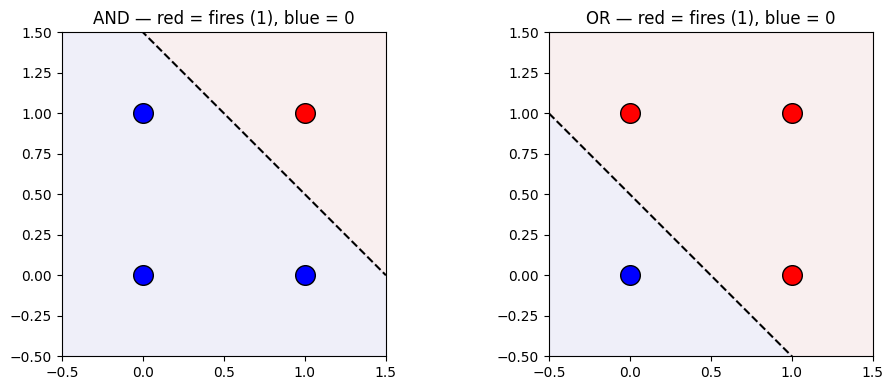

In [96]:
def plot_decision_boundary(w, b, ax, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5)):
    """Plot the decision boundary and colored regions of a 2D perceptron."""
    xs = np.linspace(*xlim, 200)  # 200 evenly spaced x-coordinates
    ys = np.linspace(*ylim, 200)  # 200 evenly spaced y-coordinates
    XX, YY = np.meshgrid(xs, ys)  # Create a 200×200 grid of (x, y) points
    grid = np.stack([XX.ravel(), YY.ravel()], axis=1)  # Flatten grid to (40000, 2) for the perceptron
    ZZ = perceptron_forward(grid, w, b).reshape(XX.shape)  # Classify every grid point, reshape to 2D
    # Fill regions with colors: blue for class 0, red for class 1
    ax.contourf(XX, YY, ZZ, levels=[-0.5, 0.5, 1.5], alpha=0.3, colors=['#cce', '#ecc'])
    # Draw the decision boundary line: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b)/w2
    if abs(w[1]) > 1e-8:  # Only draw if w2 is not zero (avoid division by zero)
        ax.plot(xs, -(w[0] * xs + b) / w[1], 'k--')  # Dashed black line
    ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')  # Set axis limits and equal scaling

# Create a 1×2 figure for AND and OR decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Loop over both gates, plotting each in its own subplot
for ax, (name, w, b) in zip(axes, [("AND", w_and, b_and), ("OR", w_or, b_or)]):
    plot_decision_boundary(w, b, ax)  # Draw the colored regions and boundary line
    out = perceptron_forward(X_bool, w, b)  # Classify the 4 Boolean input points
    for (x1, x2), o in zip(X_bool, out):
        # Plot each point: red if it fires (1), blue otherwise (0)
        ax.scatter(x1, x2, s=200, c='red' if o else 'blue', edgecolors='black', zorder=3)
    ax.set_title(f"{name} — red = fires (1), blue = 0")  # Label the subplot
plt.tight_layout(); plt.show()  # Adjust layout and display

Key geometric insight: a single perceptron can only implement **linearly separable** functions — those whose positive and negative examples can be split by a straight line (or hyperplane in higher dimensions).

**XOR is not linearly separable** — and this is exactly why a single perceptron fails on it. You can try: there is no `(w1, w2, b)` that makes the perceptron output `[0, 1, 1, 0]` on the four corners.

> Remarks from the lecture:
> * linear regression = a single neuron with a **linear** activation function,
> * logistic regression = a single neuron with a **sigmoid** activation function.

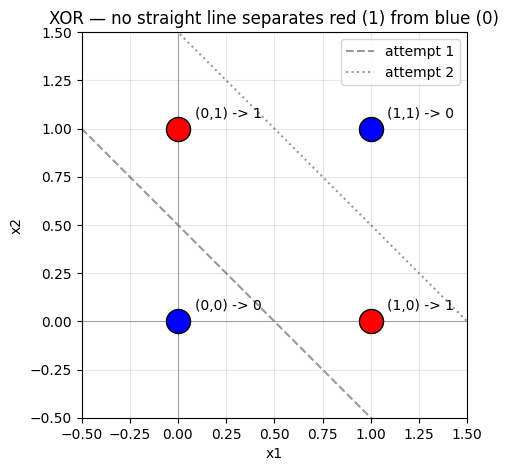

In [97]:
# --- Visualize why XOR is not linearly separable ---
# Plot the 4 XOR inputs colored by their target output and try drawing a single
# straight line that separates the red points from the blue ones — it's impossible.
xor_target = np.array([0, 1, 1, 0])  # XOR truth table outputs

fig, ax = plt.subplots(figsize=(5, 5))
for (x1, x2), t in zip(X_bool, xor_target):
    ax.scatter(x1, x2, s=300, c='red' if t else 'blue', edgecolors='black', zorder=3)
    ax.annotate(f"({x1},{x2}) -> {t}", (x1, x2), textcoords="offset points", xytext=(12, 8))

# Show two example "attempts" at separating lines — both fail to split red vs blue
xs = np.linspace(-0.5, 1.5, 100)
ax.plot(xs, 0.5 - xs, 'k--', alpha=0.4, label='attempt 1')   # x1 + x2 = 0.5
ax.plot(xs, 1.5 - xs, 'k:',  alpha=0.4, label='attempt 2')   # x1 + x2 = 1.5

ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5); ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.grid(alpha=0.3); ax.legend(loc='upper right')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title("XOR — no straight line separates red (1) from blue (0)")
plt.tight_layout(); plt.show()

### Part 4: Activation Functions

Why do we need an activation function? Two reasons:

1. **Non-linearity** — without it, stacking layers is useless: a composition of linear maps is still linear, so no matter how deep the network is it could only represent linear functions.
2. **Differentiability** — later, training via gradient descent needs the derivative of the activation. The original step function is not differentiable at 0, which is one reason modern networks use smooth alternatives.

Let's plot the most common activation functions.

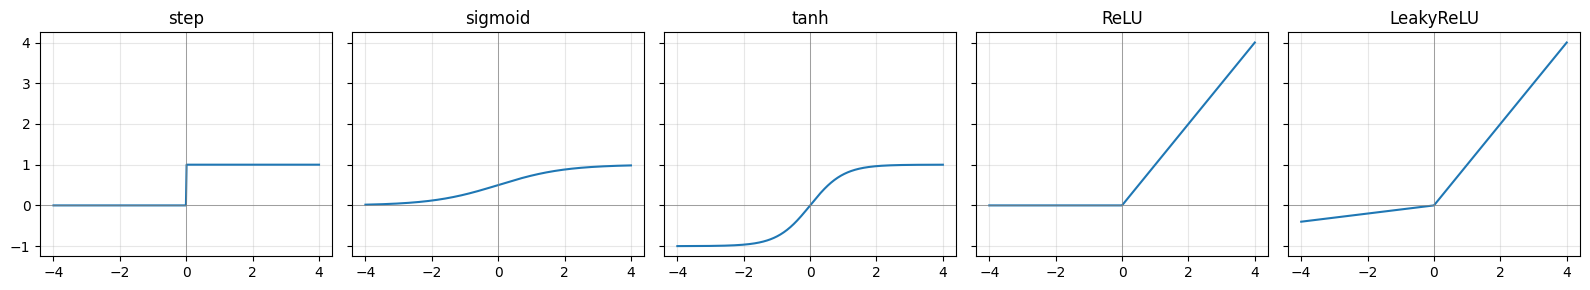

In [98]:
# --- Define common activation functions ---
def step_fn(z):   return (z >= 0).astype(float)          # Step: 0 if z<0, 1 if z>=0
def sigmoid(z):   return 1.0 / (1.0 + np.exp(-z))       # Sigmoid: smooth S-curve in (0, 1)
def tanh(z):      return np.tanh(z)                      # Tanh: zero-centered, range (-1, 1)
def relu(z):      return np.maximum(0.0, z)              # ReLU: max(0, z), most popular in modern nets
def leaky_relu(z, alpha=0.1): return np.where(z >= 0, z, alpha * z)  # LeakyReLU: small slope for z<0

z = np.linspace(-4, 4, 400)  # 400 points from -4 to 4 for plotting

# Create 1×5 subplots, sharing the y-axis for easy comparison
fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
# Plot each activation function in its own subplot
for ax, (name, f) in zip(axes, [
    ("step", step_fn), ("sigmoid", sigmoid), ("tanh", tanh),
    ("ReLU", relu), ("LeakyReLU", leaky_relu),
]):
    ax.plot(z, f(z))                                  # Plot f(z) vs z
    ax.axhline(0, color='gray', lw=0.5)              # Horizontal reference line at y=0
    ax.axvline(0, color='gray', lw=0.5)              # Vertical reference line at x=0
    ax.set_title(name); ax.grid(alpha=0.3)            # Title and light grid
plt.tight_layout(); plt.show()  # Adjust layout and display

Quick comparison:

| name       | range          | differentiable | notes |
|------------|---------------|----------------|-------|
| step       | {0, 1}        | no (at 0)      | original perceptron |
| sigmoid    | (0, 1)        | yes            | smooth, saturates → vanishing gradient |
| tanh       | (-1, 1)       | yes            | zero-centered version of sigmoid |
| ReLU       | [0, ∞)        | yes (a.e.)     | cheap, dominant in modern nets |
| LeakyReLU  | (-∞, ∞)       | yes (a.e.)     | avoids "dead" neurons |

#### Why do we actually *need* non-linearity?

A common claim in the lecture is: *"without non-linear activations, stacking layers is useless — the whole network collapses to a single linear layer."* Let's verify this numerically.

Consider two linear layers applied back-to-back, with **no activation** in between:

$$ \mathbf{y} = W^{(2)} \bigl( W^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \bigr) + \mathbf{b}^{(2)} = \underbrace{W^{(2)} W^{(1)}}_{W'} \mathbf{x} + \underbrace{W^{(2)} \mathbf{b}^{(1)} + \mathbf{b}^{(2)}}_{\mathbf{b}'} $$

So the two-layer composition is **exactly equivalent** to a single linear layer with weights $W' = W^{(2)} W^{(1)}$ and bias $\mathbf{b}' = W^{(2)} \mathbf{b}^{(1)} + \mathbf{b}^{(2)}$. No matter how many linear layers we stack, the result is still linear.

### Part 5: Solving XOR with a Multi-Layer Perceptron

Since XOR is not linearly separable, no single perceptron can solve it. But we can write XOR as a combination of simpler gates:

$$ x_1 \oplus x_2 = (x_1 \text{ OR } x_2) \text{ AND } (x_1 \text{ NAND } x_2) $$

So with **two perceptrons in a hidden layer** (one computing OR, one computing NAND) and **one perceptron in the output layer** (computing AND of the two hidden outputs), XOR becomes solvable.

This is a tiny **Multi-Layer Perceptron (MLP)**: input layer (2) → hidden layer (2) → output layer (1).

In [99]:
# --- XOR MLP: 2 hidden neurons + 1 output neuron ---

# Hidden layer: 2 neurons, each is a perceptron with hand-crafted weights
# Neuron 1 (OR):   w=[1, 1], b=-0.5  → fires if x1 + x2 >= 0.5
# Neuron 2 (NAND): w=[-1,-1], b=1.5  → fires if -x1 - x2 >= -1.5
W1 = np.array([[1.0, 1.0],     # Row 0: weights of OR neuron
               [-1.0, -1.0]])   # Row 1: weights of NAND neuron
b1 = np.array([-0.5, 1.5])     # Biases for OR and NAND neurons

# Output layer: 1 neuron doing AND of the two hidden outputs
W2 = np.array([[1.0, 1.0]])    # Weight matrix, shape (1, 2)
b2 = np.array([-1.5])          # Bias: fires only when h1 + h2 >= 1.5

def mlp_xor_forward(X):
    """Forward pass of the 2-layer XOR network."""
    h = step((X @ W1.T) + b1)      # Hidden layer: multiply inputs by W1^T, add bias, apply step
    y = step((h @ W2.T) + b2)      # Output layer: multiply hidden by W2^T, add bias, apply step
    return h, y.ravel()             # Return hidden activations and flattened output

# Run forward pass on all 4 Boolean inputs
h, y_hat = mlp_xor_forward(X_bool)

# Print truth table comparing the MLP output to the expected XOR
print("  x1 x2 | h1=OR  h2=NAND |  y=XOR  target")
print("-" * 45)
target = [0, 1, 1, 0]  # Expected XOR outputs
for (x, hi, yi, t) in zip(X_bool, h, y_hat, target):
    print(f"   {x[0]}  {x[1]} |   {hi[0]}      {hi[1]}    |   {yi}       {t}")

  x1 x2 | h1=OR  h2=NAND |  y=XOR  target
---------------------------------------------
   0  0 |   0      1    |   0       0
   0  1 |   1      1    |   1       1
   1  0 |   1      1    |   1       1
   1  1 |   1      0    |   0       0


This MLP solves XOR exactly. The **hidden layer** has transformed the inputs into a new 2D space `(h1, h2)` in which the problem **is** linearly separable, and the output neuron separates the two classes with a single hyperplane.

This is the core idea of deep learning: **stacking non-linear layers lets the network re-represent the data in a space where the task becomes easy**.

> *Universal Approximation Theorem (1989):* an MLP with a single hidden layer and sigmoid activations can approximate any continuous function to arbitrary precision — as long as the hidden layer has enough neurons. So expressivity is not the problem. The challenges are: *how many neurons?* and *how do we find the weights?* (Next lecture: training with backpropagation.)

### Part 6: Vectorized Forward Pass

So far we treated each neuron separately. In practice we always use the **vectorized** formulation.

Notation from the lecture:

* $\mathbf{a}^{(\ell)} \in \mathbb{R}^{n_\ell}$: activation vector of layer $\ell$
* $\mathbf{b}^{(\ell)} \in \mathbb{R}^{n_\ell}$: bias vector of layer $\ell$
* $W^{(\ell)} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$: weight matrix between layer $\ell-1$ and layer $\ell$
* $\varphi$: activation function, applied element-wise

Forward pass of layer $\ell$:

$$ \mathbf{z}^{(\ell)} = W^{(\ell)} \mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)} \qquad \mathbf{a}^{(\ell)} = \varphi\bigl(\mathbf{z}^{(\ell)}\bigr) $$

with $\mathbf{a}^{(0)} = \mathbf{x}$ (the input). Let's implement this for a 2-hidden-layer MLP with `tanh` activations and **random** weights (we are not training yet, we just want to see the forward pass work).

In [100]:
def forward(x, weights, biases, activation=np.tanh):
    """Generic forward pass through an MLP with arbitrary number of layers."""
    a = x                      # Initial activation is the input itself (a^(0) = x)
    activations = [a]          # Store all layer activations for inspection
    for W, b in zip(weights, biases):  # Iterate over each layer's weights and biases
        z = W @ a + b          # Pre-activation: linear transform z = W·a + b
        a = activation(z)      # Post-activation: apply non-linearity element-wise
        activations.append(a)  # Save the activation of this layer
    return a, activations      # Return final output and all intermediate activations

# --- Define a 3 → 4 → 4 → 2 MLP architecture ---
layer_sizes = [3, 4, 4, 2]    # Input dim 3, two hidden layers of 4, output dim 2
weights, biases = [], []       # Lists to hold weight matrices and bias vectors
for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):  # Iterate over consecutive layer pairs
    weights.append(np.random.randn(n_out, n_in) * 0.5)      # Random weights scaled by 0.5
    biases.append(np.random.randn(n_out) * 0.1)             # Random biases scaled by 0.1

# Run a forward pass on a single 3D input vector
x = np.array([1.0, -0.5, 2.0])
y, acts = forward(x, weights, biases)

print(f"\nFinal output y = a^({len(acts) - 1}):  {np.round(y, 3)}")


Final output y = a^(3):  [-0.186 -0.376]


**Neural networks are nested functions.** Writing the whole network as one expression:

$$ \mathbf{y} = \varphi\!\bigl( W^{(3)} \,\varphi\!\bigl( W^{(2)} \,\varphi\!\bigl( W^{(1)} \mathbf{x} + \mathbf{b}^{(1)} \bigr) + \mathbf{b}^{(2)} \bigr) + \mathbf{b}^{(3)} \bigr) $$

The signal flows *from the inside out* — that's the "forward pass". And because it is just function composition, we can compute the derivative of the output with respect to every parameter using the chain rule — that will be **backpropagation** in the next lecture.

### Part 7: Classification Setup — one-hot encoding and softmax

How do we actually use such a network for **classification**?

* **Input.** A $d$-dimensional feature vector $\mathbf{x} \in \mathbb{R}^d$.
* **Output.** A $c$-dimensional vector $\mathbf{y} \in \mathbb{R}^c$, where $c$ is the number of classes.
* **Ground truth.**
  * *Binary classification* ($c = 1$): $y \in \{0, 1\}$ directly.
  * *Multi-class* ($c$ classes): **one-hot encoding**. Class $k$ is encoded as a vector with 1 at position $k$ and 0 elsewhere.

In [101]:
def one_hot(labels, num_classes):
    """Convert a vector of class indices into one-hot encoded rows."""
    out = np.zeros((len(labels), num_classes))  # Create a (N, C) matrix of zeros
    out[np.arange(len(labels)), labels] = 1     # Set position [i, labels[i]] = 1 for each sample
    return out

labels = np.array([0, 2, 1, 9, 4])  # Example digit labels (e.g. from MNIST)
print("labels :", labels)
print("one-hot:")
print(one_hot(labels, num_classes=10))  # Encode into 10-class one-hot vectors

labels : [0 2 1 9 4]
one-hot:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


#### Softmax

The raw output of the network (called **logits**) can be any real number. To turn them into class probabilities we apply the **softmax** function:

$$ \text{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{c} e^{z_j}} $$

Properties: every component is in $(0, 1)$ and they sum to 1 — so we can read the output as a probability distribution over the $c$ classes. For numerical stability it is common to use **LogSoftmax** instead.

In [102]:
def softmax(z):
    """Compute softmax probabilities from raw logits (numerically stable)."""
    z = z - np.max(z)  # Subtract the max for numerical stability (prevents exp overflow)
    e = np.exp(z)      # Exponentiate each element
    return e / e.sum() # Normalize so all probabilities sum to 1

logits = np.array([2.0, 1.0, 0.1, -1.0, 3.5])  # Raw network outputs (unnormalized scores)
probs = softmax(logits)                           # Convert to probability distribution
print("logits:       ", np.round(logits, 2))
print("probabilities:", np.round(probs, 3))
# Verify probabilities sum to 1 and find the predicted class (highest probability)
print("sum =", probs.sum(), "   predicted class =", int(np.argmax(probs)))

logits:        [ 2.   1.   0.1 -1.   3.5]
probabilities: [0.165 0.061 0.025 0.008 0.741]
sum = 1.0    predicted class = 4


### Part 8: Introduction to PyTorch

Everything we did so far was NumPy. In practice, we use a **deep learning framework** that handles:

* **tensor** operations (like NumPy, but with GPU support),
* **automatic differentiation** — it tracks operations on tensors and computes gradients for us (so we don't have to derive backprop by hand),
* ready-made neural-network **building blocks** (`nn.Linear`, activations, losses, optimizers, ...).

The most widely used framework is [PyTorch](https://pytorch.org/). Let's get a first feel for it.

In [103]:
import torch            # PyTorch: deep learning framework with autograd and GPU support
import torch.nn as nn   # nn module: pre-built layers, activations, losses, etc.

print("PyTorch version:", torch.__version__)  # Print the installed PyTorch version

PyTorch version: 2.8.0


#### 8.1 Tensors

A `torch.Tensor` is the PyTorch equivalent of a NumPy array. Most NumPy operations have a direct counterpart.

In [104]:
# --- Basic tensor operations ---
a = torch.tensor([1.0, 2.0, 3.0])   # Create a 1D tensor from a Python list
b = torch.tensor([10.0, 20.0, 30.0])

print("a       =", a)
print("a + b   =", a + b)           # Element-wise addition
print("a.dot(b)=", a.dot(b))        # Dot product: 1*10 + 2*20 + 3*30 = 140
print("shape   =", a.shape, "   dtype =", a.dtype)  # Shape and data type

a       = tensor([1., 2., 3.])
a + b   = tensor([11., 22., 33.])
a.dot(b)= tensor(140.)
shape   = torch.Size([3])    dtype = torch.float32


#### 8.2 Autograd — automatic differentiation

The feature that makes PyTorch really useful (and that we will fully exploit in the next lecture for training) is **autograd**: if you set `requires_grad=True`, PyTorch tracks the operations you do with a tensor and can compute derivatives automatically.

In [105]:
# --- Autograd example: compute df/du for f(u) = u^2 + 3u at u = 2 ---
u = torch.tensor(2.0, requires_grad=True)  # Create a scalar tensor with gradient tracking enabled
f = u ** 2 + 3 * u                         # Define the function f(u) = u² + 3u
f.backward()                               # Backpropagate: compute df/du and store in u.grad
print("f(2)   =", f.item())                # f(2) = 4 + 6 = 10; .item() extracts a Python scalar
print("df/du  =", u.grad.item(), "  (expected: 2*2 + 3 = 7)")  # df/du = 2u + 3 = 7

f(2)   = 10.0
df/du  = 7.0   (expected: 2*2 + 3 = 7)


#### 8.3 Building a neural network with `torch.nn`

Instead of managing weight matrices and bias vectors ourselves, we use `nn.Linear(in_features, out_features)`. It contains the parameters $W$ and $\mathbf{b}$. We can stack several layers using `nn.Sequential`.

Let's build the same 3 → 4 → 4 → 2 MLP as before.

In [106]:
# Build a 3 → 4 → 4 → 2 MLP using nn.Sequential (layers applied in order)
model = nn.Sequential(
    nn.Linear(3, 4),   # Layer 1: affine transform from 3 inputs to 4 outputs (learns W and b)
    nn.Tanh(),         # Activation 1: tanh non-linearity applied element-wise
    nn.Linear(4, 4),   # Layer 2: affine transform from 4 to 4
    nn.Tanh(),         # Activation 2: tanh
    nn.Linear(4, 2),   # Layer 3: affine transform from 4 to 2 outputs
    nn.Tanh(),         # Activation 3: tanh
)
print(model)  # Print the model architecture

# Count total number of learnable parameters (weights + biases across all layers)
n_params = sum(p.numel() for p in model.parameters())  # .numel() = number of elements in tensor
print(f"\nTotal parameters: {n_params}")

# Run a forward pass on a single input vector
x_t = torch.tensor([1.0, -0.5, 2.0])  # Input tensor (3D)
y_t = model(x_t)                       # Forward pass through all layers
print("\nInput :", x_t)
print("Output:", y_t.detach())  # .detach() removes from computation graph for clean printing

Sequential(
  (0): Linear(in_features=3, out_features=4, bias=True)
  (1): Tanh()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): Tanh()
  (4): Linear(in_features=4, out_features=2, bias=True)
  (5): Tanh()
)

Total parameters: 46

Input : tensor([ 1.0000, -0.5000,  2.0000])
Output: tensor([-0.1676,  0.1571])


Note: because PyTorch initialises weights **randomly**, the output differs from our NumPy version — we haven't aligned the weights between the two models. Let's do that explicitly, just to prove the two computations agree.

In [107]:
# --- Copy our NumPy weights into the PyTorch model to verify identical computation ---
with torch.no_grad():  # Disable gradient tracking (we're just copying, not training)
    # Iterate over the Linear layers in the model and our NumPy weight/bias pairs
    for layer, (W, b) in zip(
        [m for m in model if isinstance(m, nn.Linear)],  # Filter to only nn.Linear modules
        zip(weights, biases),                             # Our NumPy weights and biases from Part 6
    ):
        layer.weight.copy_(torch.from_numpy(W).float())  # Copy weight matrix (in-place)
        layer.bias.copy_(torch.from_numpy(b).float())    # Copy bias vector (in-place)

# Compare outputs from both implementations
y_numpy, _ = forward(x, weights, biases)                     # NumPy forward pass from Part 6
y_torch   = model(torch.from_numpy(x).float()).detach().numpy()  # PyTorch forward pass, convert to NumPy

print("NumPy output  :", np.round(y_numpy, 4))
print("PyTorch output:", np.round(y_torch, 4))  # Should match exactly

NumPy output  : [-0.1858 -0.3762]
PyTorch output: [-0.1858 -0.3762]


Same computation — PyTorch is simply doing matrix multiplications and tanh under the hood, but with autograd and GPU support on top.

#### 8.4 Re-implementing the XOR MLP in PyTorch

Finally, let's re-implement our hand-crafted XOR solver from Part 5 using PyTorch modules. We'll set the weights by hand (since training comes next lecture) and use the step function as activation — note that we use `nn.Linear` for the affine part and apply the activation manually.

In [108]:
# --- XOR network as a PyTorch nn.Module ---
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()                      # Initialize the parent nn.Module
        self.hidden = nn.Linear(2, 2)           # Hidden layer: 2 inputs → 2 neurons (OR + NAND)
        self.out    = nn.Linear(2, 1)           # Output layer: 2 hidden → 1 output (AND)

    def forward(self, x):
        h = (self.hidden(x) >= 0).float()       # Step activation on hidden layer (cast bool → float)
        y = (self.out(h) >= 0).float()          # Step activation on output layer
        return y

net = XORNet()  # Instantiate the network (weights are random at this point)

# --- Set the hand-crafted weights from Part 5 ---
with torch.no_grad():  # No gradient tracking needed for manual weight assignment
    net.hidden.weight.copy_(torch.tensor([[1.0, 1.0], [-1.0, -1.0]]))  # OR and NAND weights
    net.hidden.bias.copy_(torch.tensor([-0.5, 1.5]))                    # OR and NAND biases
    net.out.weight.copy_(torch.tensor([[1.0, 1.0]]))                     # AND weights
    net.out.bias.copy_(torch.tensor([-1.5]))                             # AND bias

# Run forward pass on all 4 Boolean inputs
X_t = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])  # All 2-bit inputs as a (4,2) tensor
print("input  ->  XOR prediction")
for x, y in zip(X_t, net(X_t)):                     # Iterate over inputs and their predictions
    print(f"  {x.tolist()}  ->  {int(y.item())}")    # Print each input-output pair

input  ->  XOR prediction
  [0.0, 0.0]  ->  0
  [0.0, 1.0]  ->  1
  [1.0, 0.0]  ->  1
  [1.0, 1.0]  ->  0


#### 8.5 Inspecting a model's parameters

Every `nn.Module` exposes its learnable tensors through `.parameters()` (values only) and `.named_parameters()` (name + value). Useful for debugging, for counting parameters, or for checking that everything has the shape you expect.

In [109]:
# --- Inspect all learnable parameters in the model ---
print(f"{'name':<15} {'shape':<20} {'#params'}")
print("-" * 45)
total = 0
# .named_parameters() yields (name, tensor) for every learnable parameter
for name, p in model.named_parameters():
    n = p.numel()      # Number of scalar elements in this parameter tensor
    total += n         # Accumulate total parameter count
    print(f"{name:<15} {str(tuple(p.shape)):<20} {n}")
print("-" * 45)
print(f"{'TOTAL':<15} {'':<20} {total}")  # Print grand total

name            shape                #params
---------------------------------------------
0.weight        (4, 3)               12
0.bias          (4,)                 4
2.weight        (4, 4)               16
2.bias          (4,)                 4
4.weight        (2, 4)               8
4.bias          (2,)                 2
---------------------------------------------
TOTAL                                46


#### 8.6 Device check — CPU, CUDA GPU, Apple MPS

PyTorch runs on CPU by default, but can transparently use an accelerator if one is available:

* **CUDA** — NVIDIA GPUs
* **MPS** (Metal Performance Shaders) — Apple Silicon Macs
* **CPU** — fallback, always available

Tensors and models are moved to a device with `.to(device)`. Both the model **and** its inputs must live on the same device.

In [110]:
# --- Select the best available compute device ---
if torch.cuda.is_available():
    device = torch.device("cuda")       # NVIDIA GPU available
elif torch.backends.mps.is_available():
    device = torch.device("mps")        # Apple Silicon GPU (Metal Performance Shaders)
else:
    device = torch.device("cpu")        # Fallback: CPU

print("Using device:", device)

# Move the model and input tensor to the chosen device, then run a forward pass
model_dev = model.to(device)                                  # Transfer all model parameters to device
x_dev = torch.tensor([1.0, -0.5, 2.0], device=device)        # Create input directly on the device
y_dev = model_dev(x_dev)                                      # Forward pass on the device
print("Output device:", y_dev.device)                         # Confirm output is on the same device
print("Output       :", y_dev.detach().cpu().numpy().round(4))  # Move to CPU, convert to NumPy for printing

Using device: mps
Output device: mps:0
Output       : [-0.1858 -0.3762]


#### 8.7 Saving and loading a checkpoint

Once a model's parameters are set (either hand-crafted like here or learned through training in the next lecture), we usually want to **save** them to disk so we can reload the same model later without recomputing. The idiomatic PyTorch way is to save the **state dict** — a plain `dict` mapping parameter names to tensors.

* `torch.save(obj, path)` — serialize any Python object (typically a state dict) to a file.
* `model.state_dict()` — get the current parameters.
* `model.load_state_dict(sd)` — load parameters into an existing model of the **same architecture**.

A common convention is the `.pt` (or `.pth`) file extension.

In [111]:
# --- Save the XOR network's learned parameters to disk ---
torch.save(net.state_dict(), "xor_net.pt")  # Serialize the state dict (weights + biases) to a .pt file
print("Saved xor_net.pt — keys:", list(net.state_dict().keys()))  # Show the parameter names stored

# --- Demonstrate loading: create a fresh network with random weights ---
net_fresh = XORNet()  # New instance — weights are randomly initialized
print("\nBefore loading (random weights):")
for x in X_t:
    print(f"  {x.tolist()} -> {int(net_fresh(x).item())}")  # Outputs will be wrong (random weights)

# --- Load the saved checkpoint into the fresh instance ---
net_fresh.load_state_dict(torch.load("xor_net.pt"))  # Restore the hand-crafted weights from disk
print("\nAfter loading (restored weights):")
for x in X_t:
    print(f"  {x.tolist()} -> {int(net_fresh(x).item())}")  # Now outputs match the original XOR network

Saved xor_net.pt — keys: ['hidden.weight', 'hidden.bias', 'out.weight', 'out.bias']

Before loading (random weights):
  [0.0, 0.0] -> 1
  [0.0, 1.0] -> 1
  [1.0, 0.0] -> 1
  [1.0, 1.0] -> 1

After loading (restored weights):
  [0.0, 0.0] -> 0
  [0.0, 1.0] -> 1
  [1.0, 0.0] -> 1
  [1.0, 1.0] -> 0


### Summary

In this lab we covered:

* **End-to-end learning** learns features and classifier jointly, in contrast to traditional pipelines with handcrafted features.
* The **McCulloch-Pitts neuron** is the simplest artificial neuron but has severe limitations (boolean only, no weights, no learning, XOR fails).
* The **Rosenblatt perceptron** introduces weights and real-valued inputs, but still implements only a linear decision boundary.
* **Activation functions** (sigmoid, tanh, ReLU, ...) provide the non-linearity we need to stack layers meaningfully.
* An **MLP** can solve non-linearly-separable problems like XOR by re-representing the input in a space where it becomes linearly separable.
* A network's forward pass is **nothing but a nested function** `y = φ(W^(L) ... φ(W^(1) x + b^(1)) ... + b^(L))`, easily written vectorized with matrix multiplications.
* For classification we combine this with **one-hot encoding** on the target side and **softmax** on the output side.
* **PyTorch** gives us tensors, autograd, and ready-made building blocks (`nn.Linear`, `nn.Sequential`, `nn.Module`). We saw how to **inspect parameters**, move a model to a **CPU / CUDA / MPS** device, and **save / load checkpoints** via `state_dict`.

**Next lecture:** how to actually **learn** the weights from data — loss functions, gradient descent, and backpropagation.